# EfficientNetV2S - KHOTAA Diabetic Foot Ulcer Classification

## 1. Imports & Configuration

In [7]:
import sys
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights
import numpy as np
from sklearn.model_selection import StratifiedKFold

sys.path.append('../')
sys.path.append('./')

from dataset_loader import SplitFolderDatasetLoader
from dataset_preprocessing import DFUPreprocessing
from utils.checkpoint_manager import CheckpointManager
from utils.training_engine import TrainingEngine, create_optimizer
from utils.metrics_evaluator import (
    calculate_metrics, print_metrics, plot_confusion_matrix,
    plot_roc_curve, plot_training_history
)

print("Imports complete")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


Imports complete
PyTorch version: 2.10.0+cpu
CUDA available: False


## 2. Load Dataset

In [2]:
# Load dataset 
loader = SplitFolderDatasetLoader(root_dir='../../dataset')
classes = loader.get_classes()
num_classes = loader.get_num_classes()

print(f"Classes: {classes}")
print(f"Number of classes: {num_classes}")

# Initialize preprocessing
preprocessor = DFUPreprocessing()
train_transform = preprocessor.get_train_transforms()
val_test_transform = preprocessor.get_valid_test_transforms()

# Dataset class
class DFUDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        from PIL import Image
        image = Image.open(self.image_paths[idx]).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, self.labels[idx]

# Prepare data for cross-validation
X_train, y_train = loader.load_split_paths('train', shuffle=True)
X_val, y_val = loader.load_split_paths('valid')
X_all = np.concatenate([X_train, X_val])
y_all = np.concatenate([y_train, y_val])

# Test set (untouched until final evaluation)
X_test, y_test = loader.load_split_paths('test')
test_dataset = DFUDataset(X_test, y_test, transform=val_test_transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

# Initialize 5-fold stratified cross-validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"\nTotal training samples (train+valid): {len(X_all)}")
print(f"Test samples: {len(X_test)}")
print("Dataset loaded and ready for 5-fold cross-validation")

[DatasetLoader] Root: c:\Users\sara2\Documents\KHOTAA\dataset
[DatasetLoader] Splits: ['train', 'valid', 'test']
[DatasetLoader] Classes (4): ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Classes: ['Grade 1', 'Grade 2', 'Grade 3', 'Grade 4']
Number of classes: 4
[DFUPreprocessing] Initialized
[DFUPreprocessing] Image size: 224x224
[DFUPreprocessing] Train: with augmentation
[DFUPreprocessing] Valid/Test: no augmentation
[DatasetLoader] Split 'train': 9639 images
[DatasetLoader] Split 'valid': 282 images
[DatasetLoader] Split 'test': 141 images

Total training samples (train+valid): 9921
Test samples: 141
Dataset loaded and ready for 5-fold cross-validation


## 3. Model Definition

In [3]:
# Setup device and loss function
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = nn.CrossEntropyLoss()

print(f"Device: {device}")

# Create EfficientNetV2S model
def create_efficientnet_model(num_classes=4, pretrained=True):
    """
    Create EfficientNetV2S model for DFU classification.
    
    EfficientNetV2S:
    - 20.2M parameters
    - Input: 224x224 RGB
    - Output: num_classes
    """
    
    # Load pretrained model
    if pretrained:
        model = models.efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)
        print("Loaded pretrained ImageNet weights")
    else:
        model = models.efficientnet_v2_s(weights=None)
        print("Using random initialization")
    
    # EfficientNetV2S classifier is: Linear(1280 -> 1000)
    # Replace with: Linear(1280 -> num_classes)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Total parameters: {total_params:,}")
    
    return model

# Test model creation
print("\n" + "="*60)
print("MODEL CONFIGURATION & STATISTICS")
print("="*60)

test_model = create_efficientnet_model(num_classes=num_classes, pretrained=True)

# Display model info
print(f"\nModel Architecture:")
print(f"  - Name: EfficientNetV2S")
print(f"  - Input size: 224x224 (RGB)")
print(f"  - Output classes: {num_classes}")
print(f"  - Feature dimension: 1280")

print(f"\nModel Layers:")
print(f"  - Feature extraction blocks: {len(list(test_model.features))}")
print(f"  - Classifier layers: 2")

print(f"\nFinal classifier:")
print(f"  Layer 1 (Dropout): {test_model.classifier[0]}")
print(f"  Layer 2 (Linear): {test_model.classifier[1]}")

print(f"\n" + "="*60)


Device: cpu

MODEL CONFIGURATION & STATISTICS
Loaded pretrained ImageNet weights
Total parameters: 20,182,612

Model Architecture:
  - Name: EfficientNetV2S
  - Input size: 224x224 (RGB)
  - Output classes: 4
  - Feature dimension: 1280

Model Layers:
  - Feature extraction blocks: 8
  - Classifier layers: 2

Final classifier:
  Layer 1 (Dropout): Dropout(p=0.2, inplace=True)
  Layer 2 (Linear): Linear(in_features=1280, out_features=4, bias=True)



## 4. Training

In [4]:
# 5-Fold Cross-Validation Training
fold_results = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_all, y_all), 1):
    print(f"\n{'='*60}\nFOLD {fold}/5\n{'='*60}")
    
    # Prepare fold data
    X_train_fold = [X_all[i] for i in train_idx]
    y_train_fold = y_all[train_idx]
    X_val_fold = [X_all[i] for i in val_idx]
    y_val_fold = y_all[val_idx]
    
    train_dataset = DFUDataset(X_train_fold, y_train_fold, transform=train_transform)
    val_dataset = DFUDataset(X_val_fold, y_val_fold, transform=val_test_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
    val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
    
    # Create model
    model = create_efficientnet_model(num_classes=num_classes, pretrained=True)
    model = model.to(device)
    
    # Setup optimizer using helper function (SGD with momentum=0.8)
    optimizer = create_optimizer(model, lr=0.001)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.1)
    checkpoint_manager = CheckpointManager(base_dir='checkpoints', experiment_name=f'efficientnetv2s_fold{fold}')
    engine = TrainingEngine(model=model, device=device)
    
    # Train
    history = engine.train(
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        num_epochs=30,
        scheduler=scheduler,
        checkpoint_manager=checkpoint_manager,
        early_stopping_patience=7,
        use_early_stopping=True,
        verbose=True
    )
    
    # Store results
    best_val_acc = max(history['val_acc'])
    fold_results.append({
        'fold': fold,
        'best_val_acc': best_val_acc,
        'final_val_acc': history['val_acc'][-1],
        'stopped_epoch': history['stopped_epoch'],
        'history': history,
        'checkpoint_manager': checkpoint_manager
    })
    print(f"Fold {fold} - Best Acc: {best_val_acc*100:.2f}% (stopped at epoch {history['stopped_epoch']})")

# Cross-validation summary
avg_acc = np.mean([r['best_val_acc'] for r in fold_results])
std_acc = np.std([r['best_val_acc'] for r in fold_results])
avg_epochs = np.mean([r['stopped_epoch'] for r in fold_results])

print(f"\n{'='*60}")
print(f"5-FOLD CROSS-VALIDATION RESULTS")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"\nIndividual Fold Results:")
for r in fold_results:
    print(f"  Fold {r['fold']}: {r['best_val_acc']*100:.2f}% (epoch {r['stopped_epoch']})")
print(f"{'='*60}")


FOLD 1/5
Loaded pretrained ImageNet weights
Total parameters: 20,182,612
Created SGD optimizer: lr=0.001, momentum=0.8, weight_decay=0.0001
Training on: cpu

Epoch 1/30


Evaluating: 100%|██████████| 63/63 [02:04<00:00,  1.98s/it, loss=0.4152, acc=57.38%]


Learning Rate: 0.001000

Epoch 1 Results:
   Train Loss: 1.2875 | Train Acc: 40.66%
   Val Loss:   1.1286 | Val Acc:   57.38%
SUCCESS: Checkpoint saved: checkpoints\efficientnetv2s_fold1\fold_1\checkpoint_epoch_1.pth
SUCCESS: Best model saved: checkpoints\efficientnetv2s_fold1\fold_1\best_accuracy.pt
New best model! Val Acc: 57.38%

Epoch 2/30


Evaluating: 100%|██████████| 63/63 [02:02<00:00,  1.94s/it, loss=0.0225, acc=66.40%]


Learning Rate: 0.001000

Epoch 2 Results:
   Train Loss: 1.0176 | Train Acc: 58.43%
   Val Loss:   0.8558 | Val Acc:   66.40%
SUCCESS: Checkpoint saved: checkpoints\efficientnetv2s_fold1\fold_1\checkpoint_epoch_2.pth
SUCCESS: Best model saved: checkpoints\efficientnetv2s_fold1\fold_1\best_accuracy.pt
New best model! Val Acc: 66.40%

Epoch 3/30


...

Learning Rate: 0.000010

Epoch 28 Results:
   Train Loss: 0.1510 | Train Acc: 94.92%
   Val Loss:   0.1139 | Val Acc:   97.08%
SUCCESS: Checkpoint saved: checkpoints\efficientnetv2s_fold5\fold_1\checkpoint_epoch_28.pth

Epoch 29/30


Evaluating: 100%|██████████| 62/62 [01:41<00:00,  1.63s/it, loss=1.7622, acc=97.28%]


Learning Rate: 0.000010

Epoch 29 Results:
   Train Loss: 0.1414 | Train Acc: 95.33%
   Val Loss:   0.1223 | Val Acc:   97.28%
SUCCESS: Checkpoint saved: checkpoints\efficientnetv2s_fold5\fold_1\checkpoint_epoch_29.pth

Epoch 30/30


Evaluating: 100%|██████████| 62/62 [01:40<00:00,  1.63s/it, loss=1.5183, acc=96.67%]


Learning Rate: 0.000001

Epoch 30 Results:
   Train Loss: 0.1488 | Train Acc: 95.16%
   Val Loss:   0.1192 | Val Acc:   96.67%
SUCCESS: Checkpoint saved: checkpoints\efficientnetv2s_fold5\fold_1\checkpoint_epoch_30.pth
SUCCESS: Early stopping triggered at epoch 30
Best validation loss was 0.1095 at epoch 23

SUCCESS: Training stopped early at epoch 30/30
Best Validation Accuracy: 97.43%

Fold 5 - Best Acc: 97.43% (stopped at epoch 30)

5-FOLD CROSS-VALIDATION RESULTS
Mean Accuracy: 97.81% ± 0.38%
Average Epochs: 29.6

Individual Fold Results:
  Fold 1: 98.09% (epoch 28)
  Fold 2: 98.19% (epoch 30)
  Fold 3: 98.08% (epoch 30)
  Fold 4: 97.28% (epoch 30)
  Fold 5: 97.43% (epoch 30)


## 5. 5-Fold Cross-validation Results & Analysis 

✓ Results directory created: results\efficientnetv2s
✓ Directory verified: c:\Users\sara2\Documents\KHOTAA\models\classification\results\efficientnetv2s
Using random initialization
Total parameters: 20,182,612
✓ Loaded best model from checkpoints/efficientnetv2s_fold2/fold_1/best_accuracy.pt


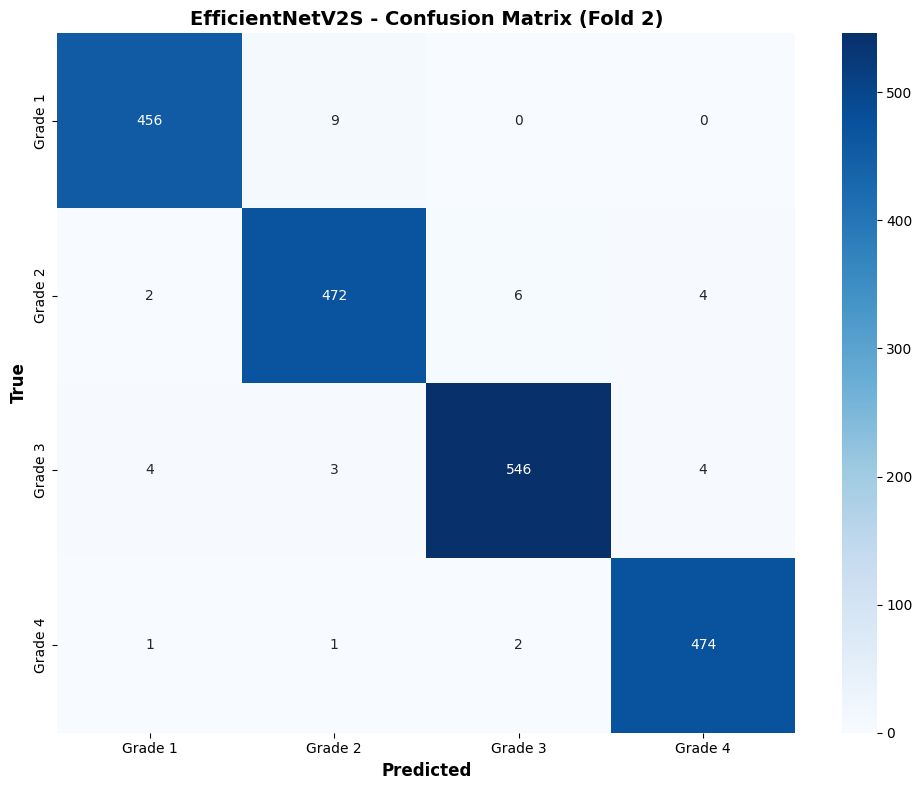


 Generating aggregated confusion matrix across all folds...
Using random initialization
Total parameters: 20,182,612
  ✓ Fold 1 processed
Using random initialization
Total parameters: 20,182,612
  ✓ Fold 2 processed
Using random initialization
Total parameters: 20,182,612


In [ ]:
# Configuration
MODEL_NAME = 'EfficientNetV2S'
BATCH_SIZE = 32
RESULTS_DIR = 'results'
CHECKPOINT_DIR = 'checkpoints'
N_FOLDS = 5
DPI = 300

# Plotting configuration
PLOT_CONFIG = {
    'cm': {'size': (10, 8), 'cmap': 'Blues'},
    'roc': {'size': (10, 8), 'lw': 2},
    'history': {'size': (18, 10)},
    'comparison': {'size': (10, 6)}
}
FONT = {'title': 14, 'label': 12, 'legend': 10, 'tick': 10}

# Save Cross-Validation Results and Generate Plots
import json
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns

# Create model-specific results directory
model_results_dir = os.path.join(RESULTS_DIR, MODEL_NAME.lower())
os.makedirs(model_results_dir, exist_ok=True)
print(f"✓ Results directory created: {model_results_dir}")

# Verify directory exists
if os.path.exists(model_results_dir):
    print(f"✓ Directory verified: {os.path.abspath(model_results_dir)}")
else:
    print(f"⚠ Warning: Directory not found, creating again...")
    os.makedirs(model_results_dir, exist_ok=True)

# Get best fold
best_fold_idx = np.argmax([r['best_val_acc'] for r in fold_results])
best_fold_num = fold_results[best_fold_idx]['fold']

# Recreate validation set for best fold
fold_splits = list(kfold.split(X_all, y_all))
train_idx, val_idx = fold_splits[best_fold_idx]
val_dataset = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Load best model
checkpoint_path = f'{CHECKPOINT_DIR}/efficientnetv2s_fold{best_fold_num}/fold_1/best_accuracy.pt'

# Check if checkpoint exists
if not os.path.exists(checkpoint_path):
    print(f"Warning: Checkpoint not found at {checkpoint_path}")
else:
    model = create_efficientnet_model(num_classes=num_classes, pretrained=False)
    model.load_state_dict(torch.load(checkpoint_path))
    model = model.to(device).eval()
    print(f"✓ Loaded best model from {checkpoint_path}")

# Get predictions
all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
        all_labels.append(labels.numpy())

predictions = np.concatenate(all_preds)
true_labels = np.concatenate(all_labels)
y_pred_proba = np.vstack(all_probs)

# 1. Confusion Matrix (Raw Counts)
cm = confusion_matrix(true_labels, predictions)

fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm, annot=True, fmt='d', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Confusion Matrix (Fold {best_fold_num})', 
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 2. Aggregated Confusion Matrix (All 5 Folds)
print("\n Generating aggregated confusion matrix across all folds...")
cm_aggregated = np.zeros((num_classes, num_classes), dtype=int)

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits, 1):
    # Recreate validation set for this fold
    val_dataset_fold = DFUDataset(X_all[val_idx], y_all[val_idx], transform=val_test_transform)
    val_loader_fold = DataLoader(val_dataset_fold, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    
    # Load model for this fold
    fold_checkpoint_path = f'{CHECKPOINT_DIR}/efficientnetv2s_fold{fold_idx}/fold_1/best_accuracy.pt'
    if os.path.exists(fold_checkpoint_path):
        model_fold = create_efficientnet_model(num_classes=num_classes, pretrained=False)
        model_fold.load_state_dict(torch.load(fold_checkpoint_path))
        model_fold = model_fold.to(device).eval()
        
        # Get predictions for this fold
        fold_preds, fold_labels = [], []
        with torch.no_grad():
            for inputs, labels in val_loader_fold:
                outputs = model_fold(inputs.to(device))
                fold_preds.append(torch.max(outputs, 1)[1].cpu().numpy())
                fold_labels.append(labels.numpy())
        
        # Accumulate confusion matrix
        fold_predictions = np.concatenate(fold_preds)
        fold_true_labels = np.concatenate(fold_labels)
        cm_fold = confusion_matrix(fold_true_labels, fold_predictions, labels=range(num_classes))
        cm_aggregated += cm_fold
        print(f"  ✓ Fold {fold_idx} processed")
    else:
        print(f"  ⚠ Fold {fold_idx} checkpoint not found, skipping")

# Normalize aggregated confusion matrix
cm_aggregated_norm = cm_aggregated.astype('float') / cm_aggregated.sum(axis=1)[:, np.newaxis]

# Plot aggregated confusion matrix
fig, ax = plt.subplots(figsize=PLOT_CONFIG['cm']['size'])
sns.heatmap(cm_aggregated_norm, annot=True, fmt='.2%', cmap=PLOT_CONFIG['cm']['cmap'],
            xticklabels=classes, yticklabels=classes, ax=ax)
ax.set_xlabel('Predicted', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('True', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - Aggregated Confusion Matrix (5-Fold CV)', 
             fontsize=FONT['title'], fontweight='bold')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_confusion_matrix_aggregated.png', dpi=DPI, bbox_inches='tight')
plt.show()

print(f"✓ Aggregated confusion matrix saved ({cm_aggregated.sum()} total predictions)")

# 3. ROC Curve
y_true_bin = label_binarize(true_labels, classes=range(num_classes))
fig, ax = plt.subplots(figsize=PLOT_CONFIG['roc']['size'])

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    ax.plot(fpr, tpr, linewidth=PLOT_CONFIG['roc']['lw'], 
            label=f'{classes[i]} (AUC={auc(fpr, tpr):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax.set_xlabel('FPR', fontsize=FONT['label'], fontweight='bold')
ax.set_ylabel('TPR', fontsize=FONT['label'], fontweight='bold')
ax.set_title(f'{MODEL_NAME} - ROC Curve (Fold {best_fold_num})', 
             fontsize=FONT['title'], fontweight='bold')
ax.legend(loc='lower right', fontsize=FONT['legend'])
ax.grid(alpha=0.3)
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_roc_curve.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 4. All Folds Training History (Loss)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Loss)', fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    history = r['history']
    epochs = range(1, len(history['train_loss']) + 1)
    
    ax.plot(epochs, history['train_loss'], 'b-', label='Train', lw=2)
    ax.plot(epochs, history['val_loss'], 'r-', label='Val', lw=2)
    ax.axvline(x=history['val_loss'].index(min(history['val_loss'])) + 1, 
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(epochs):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Loss', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_loss.png', dpi=DPI, bbox_inches='tight')
plt.show()

# 5. All Folds Training History (Accuracy)
fig, axes = plt.subplots(2, 3, figsize=PLOT_CONFIG['history']['size'])
fig.suptitle(f'{MODEL_NAME} - {N_FOLDS}-Fold CV (Accuracy)', fontsize=FONT['title']+2, fontweight='bold')

for idx, r in enumerate(fold_results):
    ax = axes[idx // 3, idx % 3]
    history = r['history']
    epochs = range(1, len(history['train_acc']) + 1)
    
    # Convert to percentage
    train_acc_pct = [acc * 100 for acc in history['train_acc']]
    val_acc_pct = [acc * 100 for acc in history['val_acc']]
    
    ax.plot(epochs, train_acc_pct, 'b-', label='Train', lw=2)
    ax.plot(epochs, val_acc_pct, 'r-', label='Val', lw=2)
    ax.axvline(x=history['val_acc'].index(max(history['val_acc'])) + 1, 
               color='g', linestyle='--', alpha=0.5, label='Best Val')
    if r['stopped_epoch'] < len(epochs):
        ax.axvline(x=r['stopped_epoch'], color='orange', linestyle='--', alpha=0.5, label='Stopped')
    
    ax.set_xlabel('Epoch', fontsize=FONT['tick'])
    ax.set_ylabel('Accuracy (%)', fontsize=FONT['tick'])
    ax.set_title(f"Fold {r['fold']}: {r['best_val_acc']*100:.2f}%", fontweight='bold')
    ax.legend(fontsize=FONT['tick']-2)
    ax.grid(alpha=0.3)
    ax.set_ylim([0, 100])

axes[1, 2].axis('off')
plt.tight_layout()
os.makedirs(model_results_dir, exist_ok=True)
plt.savefig(f'{model_results_dir}/{MODEL_NAME.lower()}_all_folds_accuracy.png', dpi=DPI, bbox_inches='tight')
plt.show()

# Save results
results = {
    'model_name': MODEL_NAME,
    'cv_results': {
        'val_accuracy': {'mean': float(avg_acc), 'std': float(std_acc)},
        'avg_epochs': float(avg_epochs),
        'fold_results': [{'fold': r['fold'], 'best_val_acc': float(r['best_val_acc']), 
                          'stopped_epoch': int(r['stopped_epoch'])} for r in fold_results]
    },
    'best_fold': {
        'fold_number': best_fold_num, 
        'best_val_acc': float(fold_results[best_fold_idx]['best_val_acc']),
        'checkpoint_path': checkpoint_path
    }
}

os.makedirs(model_results_dir, exist_ok=True)
with open(f'{model_results_dir}/{MODEL_NAME.lower()}_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"\n{'='*60}")
print(f"{MODEL_NAME} CROSS-VALIDATION SUMMARY")
print(f"{'='*60}")
print(f"Mean Accuracy: {avg_acc*100:.2f}% ± {std_acc*100:.2f}%")
print(f"Best Fold: {best_fold_num} ({fold_results[best_fold_idx]['best_val_acc']*100:.2f}%)")
print(f"Average Epochs: {avg_epochs:.1f}")
print(f"{'='*60}")